# Social Network Analysis of *Friends* (Season 1)
Authors: Deniz Mehmet Taylan, Gustavo Depieri Fioravanti, Yarkin Yavuz, Koray Aydin, Jaki Valansi

### A Complete Report Notebook · Weeks 1, 2, 3, 5, 6, 7, 9 & 10

---

**Dataset:** Character interaction network extracted from `friends_episodes.txt` (Season 1 only, 24 episodes)  
**Scope:** Graph construction · Clustering · Centrality · Communities · Link Prediction · Random Models · Diffusion

## Introduction

This report analyses the social network of *Friends* Season 1, built from character interaction data spanning all 24 episodes of the season. Each node in the network represents a character, and each edge marks a co-appearance interaction between two characters. When the same pair interacts across multiple episodes the edge weight grows accordingly, so the graph carries information about both the existence and the intensity of relationships. Parsing was restricted strictly to Season 1, the code stops as soon as it encounters the Season 2 marker, to make sure the statistics reflect exactly the material being studied.

The network is undirected, since an interaction between two characters is naturally mutual. A weighted version is used for the initial analyses, while an unweighted, loop-free version of the largest connected component is used where the methods require it.

The report moves through the material in the order of the weekly assignments. Weeks 1 to 3 cover the basics: how large and dense the network is, how locally clustered it is, and how that clustering is distributed across nodes. Week 5 looks at which characters are most central and why. Week 6 detects communities and compares two methods for doing so. Week 7 predicts which character pairs are likely to interact in the future based on shared contacts. Weeks 9 and 10 take a more model-based approach, first asking whether a preferential attachment process can reproduce the observed structure, and then simulating how information spreads through the network under different conditions.

## Dataset & Parsing

The source file `friends_episodes.txt` contains episode markers (lines starting with `#`, such as `#s1e1`) followed by interaction lines, each listing two character names. Every interaction line adds an undirected edge between the two characters, or increments the weight of the edge if it already exists.

To keep the analysis within Season 1, the parser normalizes each marker line (removing spaces and converting to lowercase) and stops as soon as it reads `#s2e1`. Lines that are empty or start with `#` are skipped, and a small cleanup step handles a `]` artifact present in some lines of the original file.

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

G = nx.Graph()

with open('friends_episodes.txt', 'r', encoding='utf-8') as file:
    for line in file:
        raw_line = line
        marker = raw_line.strip().lower().replace(' ', '')
        if marker.startswith('#s2e1'):
            break
        if ']' in line:
            line = line.split(']')[-1]
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        nodes = line.split()
        if len(nodes) >= 2:
            u, v = nodes[0], nodes[1]
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
            else:
                G.add_edge(u, v, weight=1)

print('Season 1 graph loaded successfully.')
print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')

Season 1 graph loaded successfully.
Nodes: 126
Edges: 281


---

## Week 1 Network Construction and Basic Statistics

The first step is to build the Season 1 network and get a sense of its overall shape. We compute four basic metrics: the number of nodes and edges, the average degree, and the density. Because the graph is undirected, the average degree is simply twice the number of edges divided by the number of nodes. The density is the fraction of all possible edges that actually exist in the graph.

Two visualizations are produced. The first shows the full network with all characters, giving an honest picture of how sparse and peripheral-heavy it is. The second focuses on the top 30 characters by weighted degree, where node size reflects how many total interactions a character has and edge width reflects how often two characters appear together. This focused view makes the core structure much more readable.

--- WEEK 1 METRICS ---
Network type: Undirected
Nodes: 126
Edges: 281
Average Degree: 4.46
Density: 0.0357



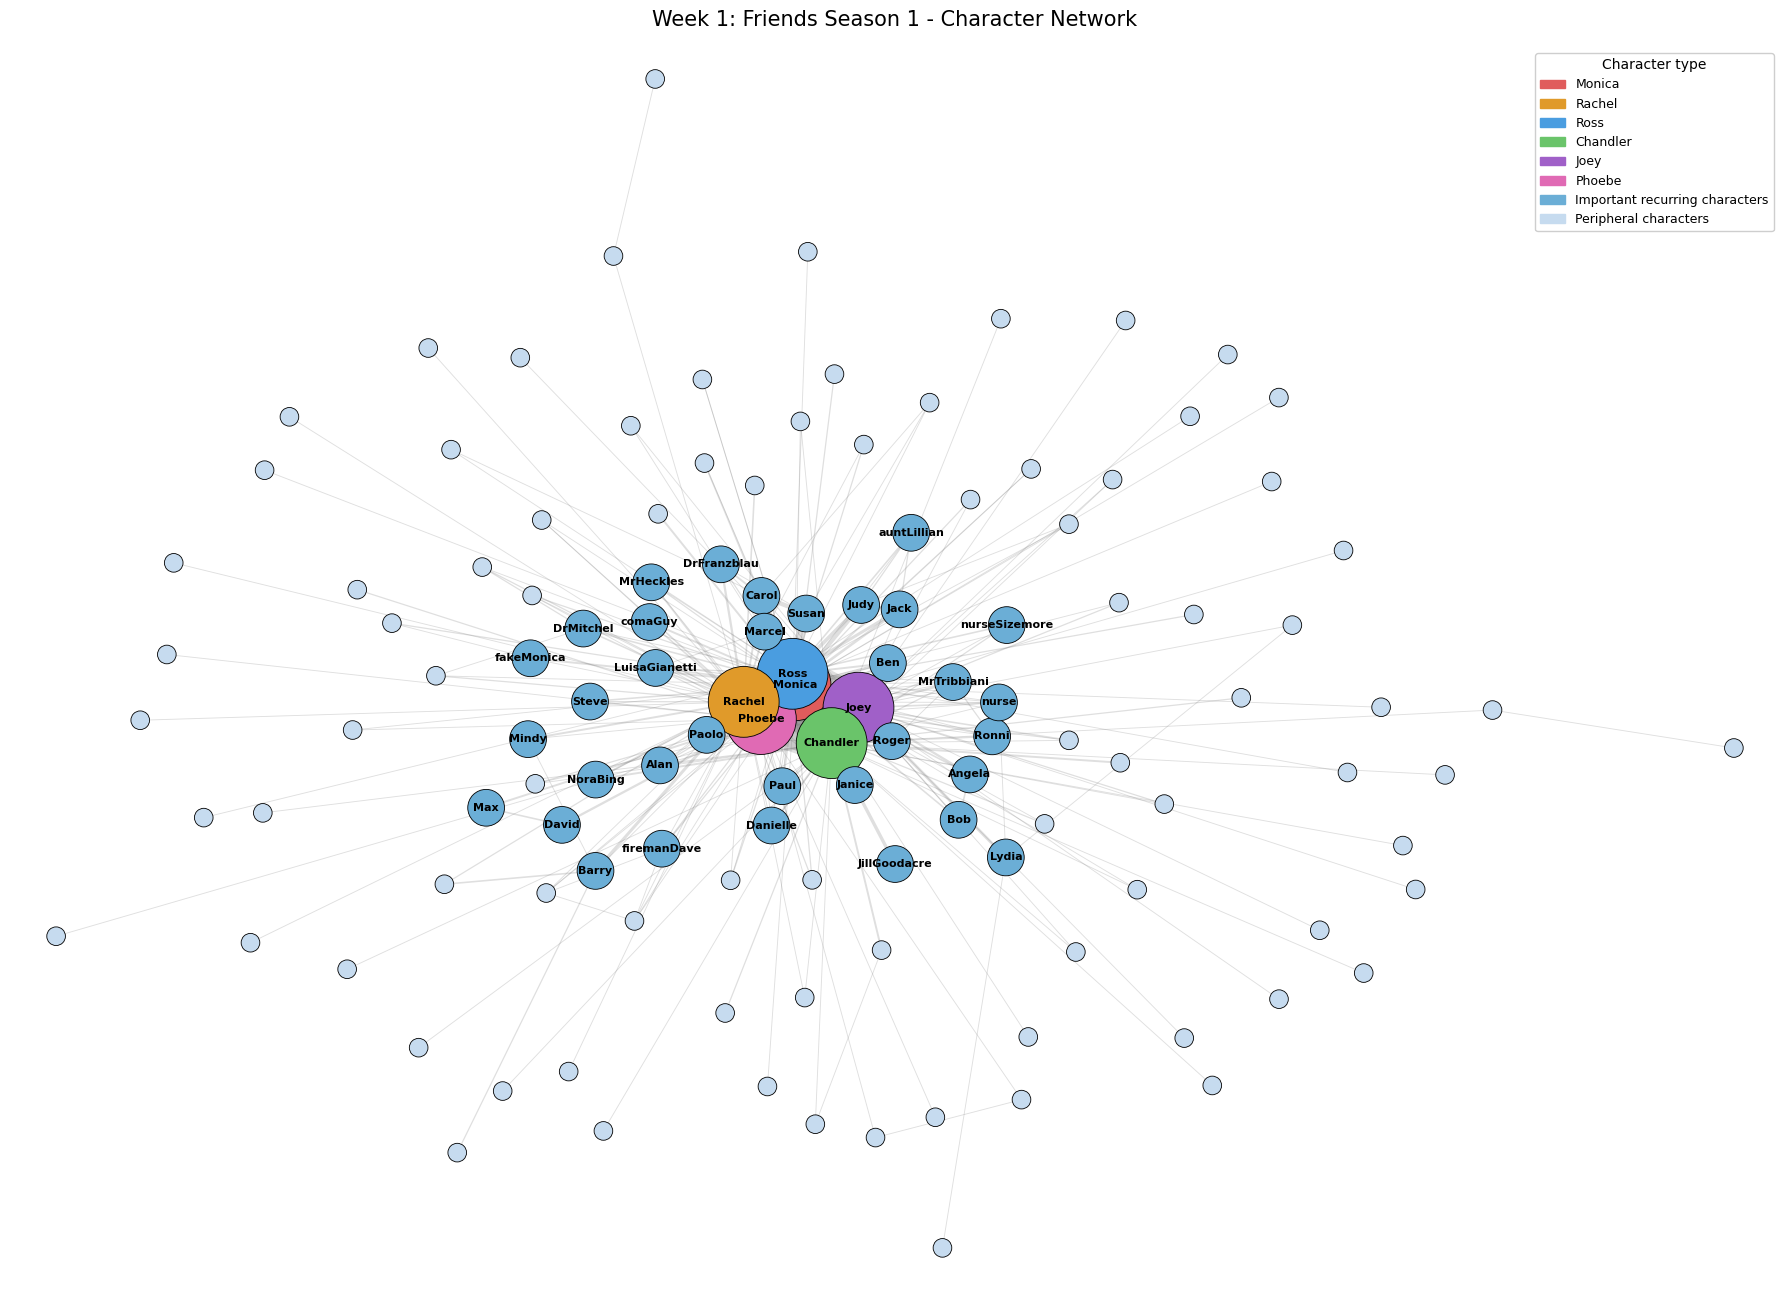

--- COMMENT ---
The network contains 126 nodes and 281 edges.
The average degree is 4.46, meaning that each character is connected on average to about 4.46 other characters.
The density is 0.0357, which suggests how sparse or connected the network is overall.
Since this is a social interaction network with many minor characters, it is expected to be relatively sparse:
the six main characters are highly connected, while many guest characters have only a few links.


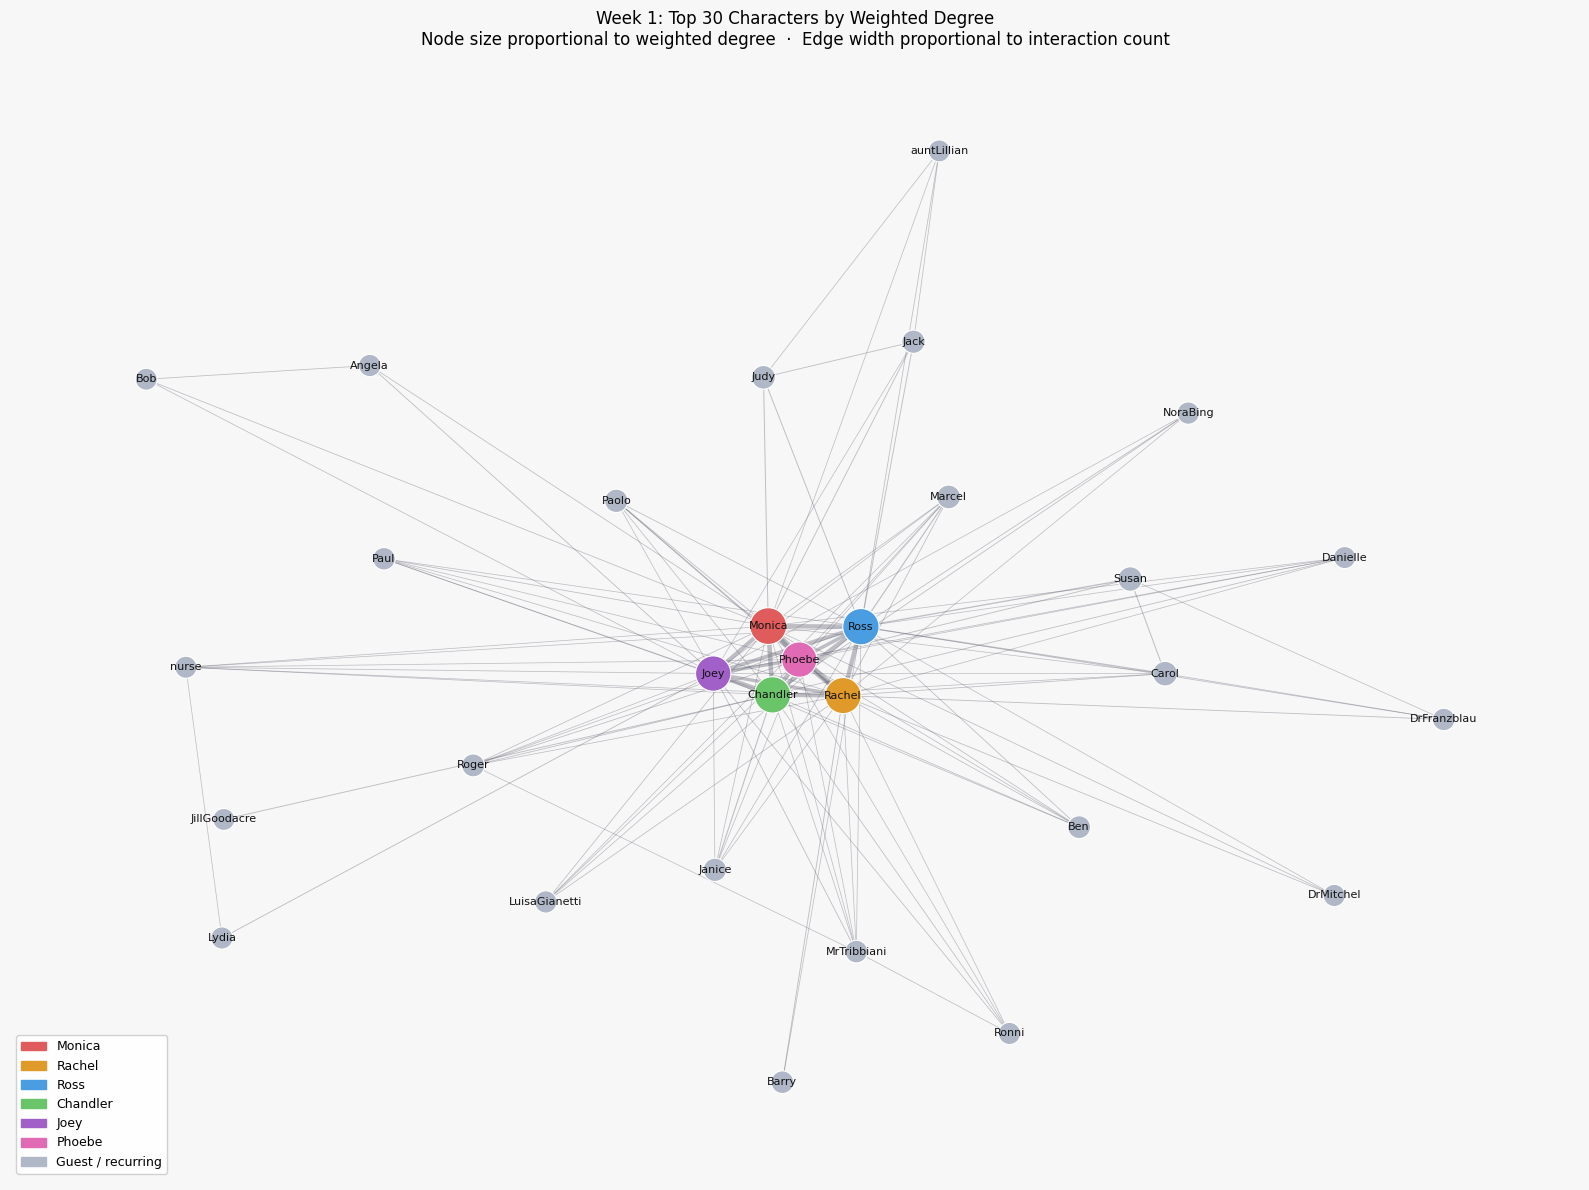

In [14]:

print('--- WEEK 1 METRICS ---')

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = (2 * num_edges) / num_nodes   
density = nx.density(G)

print(f'Network type: Undirected')
print(f'Nodes: {num_nodes}')
print(f'Edges: {num_edges}')
print(f'Average Degree: {avg_degree:.2f}')
print(f'Density: {density:.4f}\n')

MAIN_CAST = {'Monica', 'Rachel', 'Ross', 'Chandler', 'Joey', 'Phoebe'}

CAST_COLORS = {
    'Monica': '#e05c5c',
    'Rachel': '#e09a2a',
    'Ross': '#4a9de0',
    'Chandler': '#6ac46a',
    'Joey': '#a060c8',
    'Phoebe': '#e06ab4'
}

weighted_deg = dict(G.degree(weight='weight'))

pos = nx.spring_layout(
    G,
    k=2.2,
    iterations=300,
    seed=42,
    weight='weight',
    scale=3
)

for n in MAIN_CAST:
    if n in pos:
        x, y = pos[n]
        pos[n] = (x * 1.2, y * 1.2)

node_sizes = []
node_colors = []

for n in G.nodes():
    if n in MAIN_CAST:
        node_sizes.append(2600)
        node_colors.append(CAST_COLORS[n])
    elif weighted_deg.get(n, 0) >= 6:
        node_sizes.append(700)
        node_colors.append('#6baed6')
    else:
        node_sizes.append(180)
        node_colors.append('#c6dbef')

edge_widths = [0.4 + G[u][v].get('weight', 1) * 0.25 for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(18, 13))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.25,
    edge_color='gray',
    ax=ax
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='black',
    linewidths=0.6,
    ax=ax
)

labels = {
    n: n for n in G.nodes()
    if n in MAIN_CAST or weighted_deg.get(n, 0) >= 6
}

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=8,
    font_color='black',
    font_weight='bold',
    ax=ax
)

legend_handles = [mpatches.Patch(color=c, label=n) for n, c in CAST_COLORS.items()]
legend_handles.append(mpatches.Patch(color='#6baed6', label='Important recurring characters'))
legend_handles.append(mpatches.Patch(color='#c6dbef', label='Peripheral characters'))

ax.legend(
    handles=legend_handles,
    loc='upper right',
    fontsize=9,
    framealpha=0.95,
    title='Character type'
)

ax.set_title('Week 1: Friends Season 1 - Character Network', fontsize=15, pad=15)
ax.axis('off')
plt.margins(0.12)

x_vals = [x for x, y in pos.values()]
y_vals = [y for x, y in pos.values()]

margin = 0.15  
ax.set_xlim(min(x_vals) - margin, max(x_vals) + margin)
ax.set_ylim(min(y_vals) - margin, max(y_vals) + margin)
plt.tight_layout()
plt.show()




print('--- COMMENT ---')
print(f'The network contains {num_nodes} nodes and {num_edges} edges.')
print(f'The average degree is {avg_degree:.2f}, meaning that each character is connected on average to about {avg_degree:.2f} other characters.')
print(f'The density is {density:.4f}, which suggests how sparse or connected the network is overall.')
print('Since this is a social interaction network with many minor characters, it is expected to be relatively sparse:')
print('the six main characters are highly connected, while many guest characters have only a few links.')

top30 = sorted(weighted_deg, key=weighted_deg.get, reverse=True)[:30]
G_viz = G.subgraph(top30).copy()

pos_viz = nx.spring_layout(G_viz, seed=42, k=4.0, iterations=300)

node_colors2 = [CAST_COLORS.get(n, '#b0b8c8') for n in G_viz.nodes()]
max_deg = max(weighted_deg[n] for n in G_viz.nodes())
node_sizes2 = [200 + (weighted_deg[n] / max_deg) ** 0.5 * 500 for n in G_viz.nodes()]

edge_w2   = [G_viz[u][v]['weight'] for u, v in G_viz.edges()]
max_w2    = max(edge_w2) if edge_w2 else 1
edge_wid2 = [0.5 + 3.0 * (w / max_w2) for w in edge_w2]

fig2, ax2 = plt.subplots(figsize=(16, 12))
fig2.patch.set_facecolor('#f7f7f7')
ax2.set_facecolor('#f7f7f7')

nx.draw_networkx_edges(G_viz, pos_viz, width=edge_wid2, alpha=0.4,
                       edge_color='#666677', ax=ax2)
nx.draw_networkx_nodes(G_viz, pos_viz, node_size=node_sizes2, node_color=node_colors2,
                       linewidths=0.8, edgecolors='white', ax=ax2)
nx.draw_networkx_labels(G_viz, pos_viz, font_size=8, font_color='#111111', ax=ax2)

legend_handles2 = [mpatches.Patch(color=c, label=n) for n, c in CAST_COLORS.items()]
legend_handles2.append(mpatches.Patch(color='#b0b8c8', label='Guest / recurring'))
ax2.legend(handles=legend_handles2, loc='lower left', fontsize=9, framealpha=0.9)
ax2.set_title('Week 1: Top 30 Characters by Weighted Degree\n'
              'Node size proportional to weighted degree  ·  Edge width proportional to interaction count',
              fontsize=12)
ax2.axis('off')
plt.tight_layout()
plt.show()

---

## Week 2 Clustering Analysis on the Largest Connected Component

From Week 2 onwards, the analysis is restricted to the largest connected component (LCC) to avoid isolated nodes distorting the results. Two custom functions are implemented: one that computes the local clustering coefficient for a single node based on how many of its neighbors are also connected to each other, and one that averages those values across all nodes in the LCC.

The custom average is then compared against NetworkX's built-in `average_clustering` function as a correctness check, and against `transitivity`, which measures the global ratio of closed triangles. The difference between average clustering and transitivity matters: average clustering gives equal weight to every node, while transitivity is dominated by the high-degree characters at the core. When the two values diverge, it signals that clustering is not evenly distributed, which is exactly what we expect in a network built around a small group of protagonists.

In [15]:
# WEEK 2: CLUSTERING & TRANSITIVITY


largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lc = G.subgraph(largest_cc_nodes).copy()

def get_node_clustering(graph, node):
    neighbors = list(graph.neighbors(node))
    k = len(neighbors)
    if k < 2:
        return 0.0
    edges_between_neighbors = sum(1 for i in range(k) for j in range(i + 1, k)
                                  if graph.has_edge(neighbors[i], neighbors[j]))
    return (2.0 * edges_between_neighbors) / (k * (k - 1))

def get_average_clustering(graph):
    clusterings = [get_node_clustering(graph, n) for n in graph.nodes()]
    return sum(clusterings) / len(clusterings)

my_avg_clustering  = get_average_clustering(G_lc)
nx_avg_clustering  = nx.average_clustering(G_lc)
nx_transitivity    = nx.transitivity(G_lc)

print('--- WEEK 2 METRICS (Largest Connected Component) ---')
print(f'Custom Avg Clustering:   {my_avg_clustering:.4f}')
print(f'NetworkX Avg Clustering: {nx_avg_clustering:.4f}')
print(f'NetworkX Transitivity:   {nx_transitivity:.4f}')

comparison_week2 = pd.DataFrame({
    'Metric': ['Custom Avg Clustering', 'NetworkX Avg Clustering', 'NetworkX Transitivity'],
    'Value': [my_avg_clustering, nx_avg_clustering, nx_transitivity]
})
comparison_week2

--- WEEK 2 METRICS (Largest Connected Component) ---
Custom Avg Clustering:   0.5058
NetworkX Avg Clustering: 0.5058
NetworkX Transitivity:   0.1593


,Metric,Value
0,Custom Avg Clustering,0.50584
1,NetworkX Avg Clustering,0.50584
2,NetworkX Transitivity,0.15934


---

## Week 3 Cumulative Distributions

Week 3 looks at how clustering is distributed across the network rather than just reporting an average. For each node in the LCC we compute two values: its own clustering coefficient, and the average clustering coefficient of its immediate neighbors. These capture different things, one reflects how triangulated a character's own social circle is, the other reflects what kind of neighborhood that character is embedded in.

Both distributions are plotted as empirical CDFs, which show the full shape of each distribution without imposing any parametric assumptions. We produce separate plots for each and then overlay them for direct comparison. If the two curves are shifted relative to each other it means there is a systematic asymmetry in who connects to whom, for example, peripheral characters with low clustering of their own being connected to central characters who sit in highly triangulated regions.

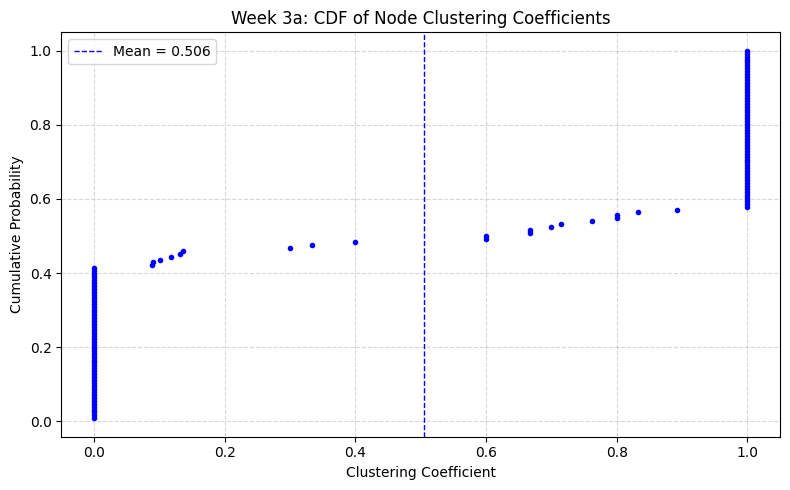

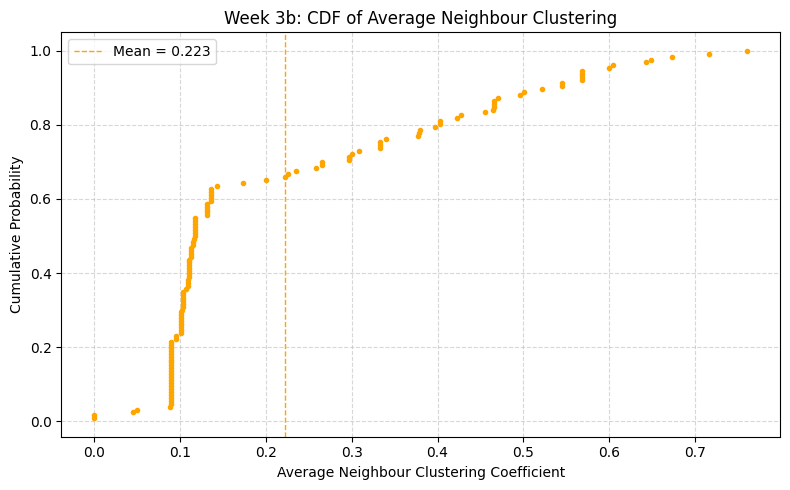

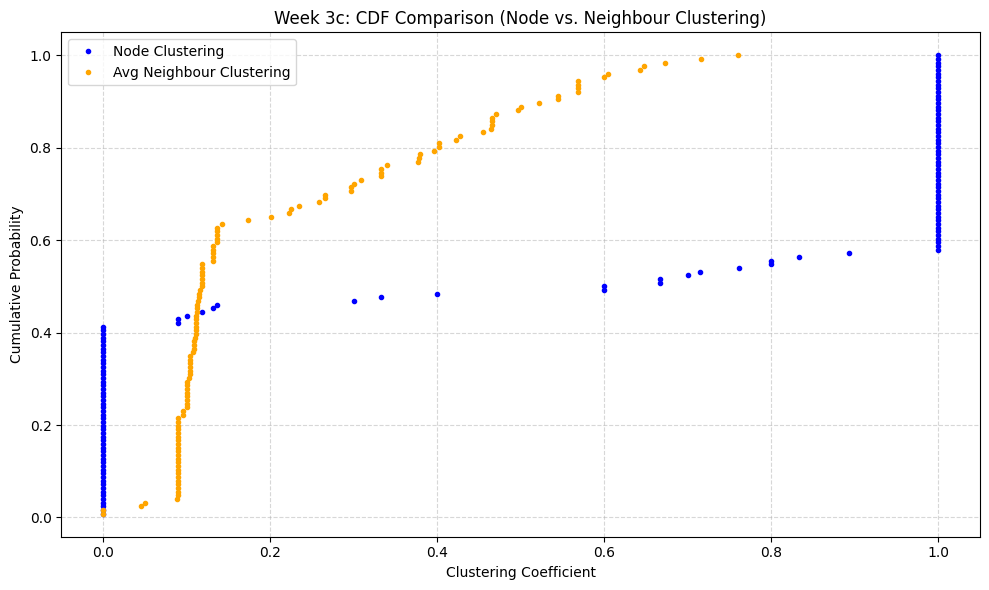

In [16]:
# WEEK 3: DISTRIBUTIONS


node_clusterings = [get_node_clustering(G_lc, n) for n in G_lc.nodes()]

def get_avg_neighbor_clustering(graph, node):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return 0.0
    return sum(get_node_clustering(graph, nb) for nb in neighbors) / len(neighbors)

neighbor_clusterings = [get_avg_neighbor_clustering(G_lc, n) for n in G_lc.nodes()]

def get_cdf_data(data):
    sorted_data = np.sort(data)
    p = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, p

x_node, y_node         = get_cdf_data(node_clusterings)
x_neighbor, y_neighbor = get_cdf_data(neighbor_clusterings)


plt.figure(figsize=(8, 5))
plt.plot(x_node, y_node, marker='.', linestyle='none', color='blue')
plt.axvline(np.mean(node_clusterings), color='blue', linestyle='--',
            linewidth=1, label=f'Mean = {np.mean(node_clusterings):.3f}')
plt.title('Week 3a: CDF of Node Clustering Coefficients')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(x_neighbor, y_neighbor, marker='.', linestyle='none', color='orange')
plt.axvline(np.mean(neighbor_clusterings), color='orange', linestyle='--',
            linewidth=1, label=f'Mean = {np.mean(neighbor_clusterings):.3f}')
plt.title('Week 3b: CDF of Average Neighbour Clustering')
plt.xlabel('Average Neighbour Clustering Coefficient')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(x_node, y_node, marker='.', linestyle='none',
         color='blue', label='Node Clustering')
plt.plot(x_neighbor, y_neighbor, marker='.', linestyle='none',
         color='orange', label='Avg Neighbour Clustering')
plt.title('Week 3c: CDF Comparison (Node vs. Neighbour Clustering)')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretation.** The neighbour-clustering CDF is shifted toward higher values than the node-clustering CDF. This indicates that many low-clustering peripheral characters are attached to highly clustered core characters, which is consistent with the core-periphery structure of the *Friends* Season 1 network.

---

## Week 5 Centrality Analysis

Two centrality measures are computed on the LCC. Betweenness centrality counts how often a node lies on the shortest path between two other nodes, characters with high betweenness act as bridges connecting otherwise separate parts of the network. PageRank assigns prestige based on the importance of a node's connections, not just their number, so a character connected to other highly connected characters scores highly.

Using both measures together avoids over-reading either one. A character can rank high on betweenness by sitting between two loosely connected clusters without being particularly well-connected overall, while PageRank captures a different notion of importance rooted in the density of a character's social neighborhood. Where the two measures agree, the result is robust; where they disagree, it reveals something about the different structural roles characters play. PageRank is computed using a custom weighted power-iteration routine rather than a library function.

Top 10 by Betweenness Centrality


,Character,Betweenness
0,Chandler,0.311129
1,Rachel,0.261966
2,Monica,0.255952
3,Joey,0.208204
4,Ross,0.182262
5,Phoebe,0.181999
6,Carol,0.019507
7,Barry,0.017358
8,Lydia,0.016065
9,Andrea,0.016000


Top 10 by PageRank


,Character,PageRank
0,Monica,0.136771
1,Chandler,0.133229
2,Rachel,0.125569
3,Ross,0.124420
4,Joey,0.110674
5,Phoebe,0.107663
6,Carol,0.008872
7,Susan,0.007601
8,Judy,0.005829
9,Marcel,0.005561


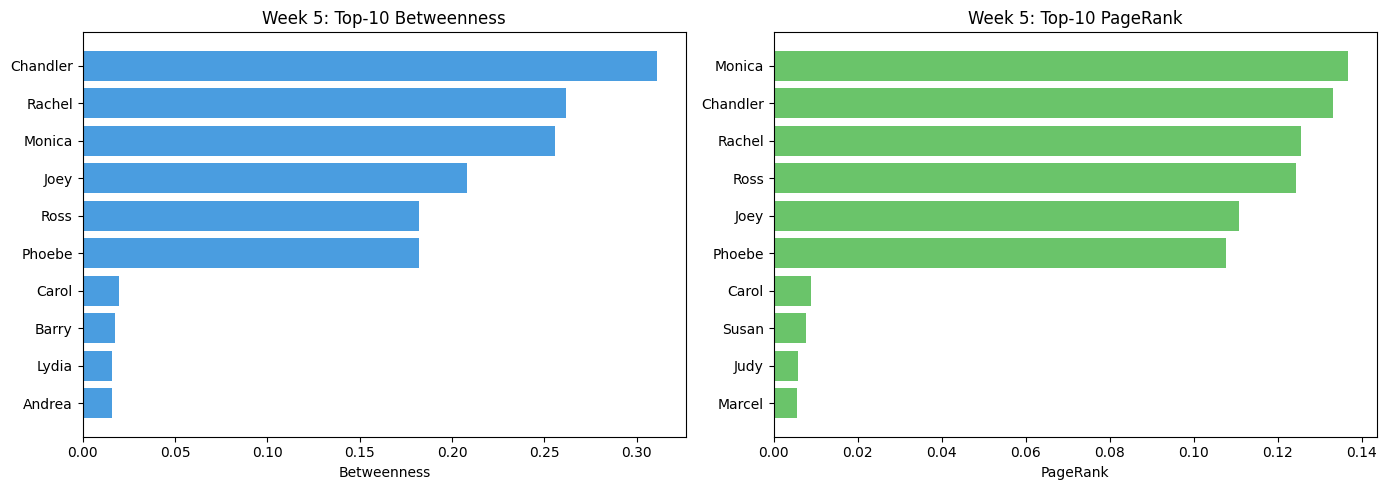

In [17]:
# WEEK 5: CENTRALITY ANALYSIS


def pagerank_power_iteration(graph, alpha=0.85, weight='weight', max_iter=200, tol=1e-12):
    nodes = list(graph.nodes())
    n = len(nodes)
    if n == 0:
        return {}

    ranks = {node: 1.0 / n for node in nodes}
    out_strength = {
        node: sum(data.get(weight, 1.0) for _, _, data in graph.edges(node, data=True))
        for node in nodes
    }
    dangling_nodes = [node for node, total in out_strength.items() if total == 0]

    for _ in range(max_iter):
        prev = ranks.copy()
        dangling_mass = alpha * sum(prev[node] for node in dangling_nodes) / n
        base = (1.0 - alpha) / n + dangling_mass
        ranks = {node: base for node in nodes}

        for u in nodes:
            total = out_strength[u]
            if total == 0:
                continue
            for v, data in graph[u].items():
                w = data.get(weight, 1.0)
                ranks[v] += alpha * prev[u] * (w / total)

        err = sum(abs(ranks[node] - prev[node]) for node in nodes)
        if err < tol:
            break

    total_rank = sum(ranks.values())
    return {node: value / total_rank for node, value in ranks.items()}

betweenness = nx.betweenness_centrality(G_lc, normalized=True, weight=None)
pagerank = pagerank_power_iteration(G_lc, alpha=0.85, weight='weight')

top10_betweenness = pd.DataFrame(
    sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10],
    columns=['Character', 'Betweenness']
)

top10_pagerank = pd.DataFrame(
    sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10],
    columns=['Character', 'PageRank']
)

print('Top 10 by Betweenness Centrality')
display(top10_betweenness)
print('Top 10 by PageRank')
display(top10_pagerank)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10_betweenness['Character'][::-1], top10_betweenness['Betweenness'][::-1], color='#4a9de0')
axes[0].set_title('Week 5: Top-10 Betweenness')
axes[0].set_xlabel('Betweenness')

axes[1].barh(top10_pagerank['Character'][::-1], top10_pagerank['PageRank'][::-1], color='#6ac46a')
axes[1].set_title('Week 5: Top-10 PageRank')
axes[1].set_xlabel('PageRank')

plt.tight_layout()
plt.show()

---

## Week 6 Community Detection

The graph is treated as undirected, unweighted, loop-free, and restricted to the largest connected component, as required. Two methods are compared: **Greedy Modularity Optimization**, which directly maximizes the modularity score Q by iteratively merging communities, and **Label Propagation**, which spreads community labels through neighborhoods until convergence. Both methods are available as NetworkX built-ins.

We select Greedy Modularity as the preferred partition. Beyond producing a higher modularity score, it is deterministic, it returns the same result every run, which makes it more suitable for a reproducible academic report. Label propagation is stochastic and can vary across runs due to random tie-breaking. The best partition is visualized below and exported to `friends_season1_best_community_partition.gexf` with a `community` node attribute for Gephi Lite exploration.

--- WEEK 6 MODULARITY COMPARISON ---
Greedy Modularity communities: 6 | modularity = 0.3632
Label Propagation communities: 7 | modularity = 0.0475


,Method,Num_Communities,Modularity
0,Greedy Modularity Optimization,6,0.363192
1,Label Propagation,7,0.047479


Best method by modularity: Greedy Modularity Optimization


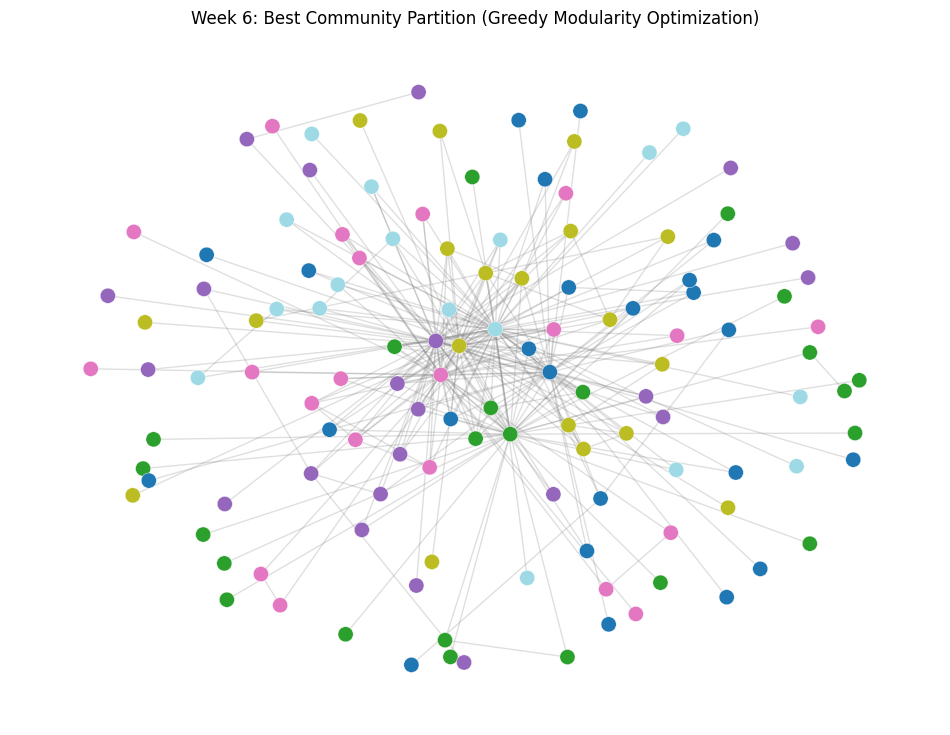

GEXF exported: friends_season1_best_community_partition.gexf


In [18]:

G_unweighted = nx.Graph()
G_unweighted.add_nodes_from(G.nodes())
G_unweighted.add_edges_from(G.edges())  
G_unweighted.remove_edges_from(nx.selfloop_edges(G_unweighted))

largest_cc_nodes_unweighted = max(nx.connected_components(G_unweighted), key=len)
G_lcc_unweighted = G_unweighted.subgraph(largest_cc_nodes_unweighted).copy()


communities_mod = list(nx.algorithms.community.greedy_modularity_communities(G_lcc_unweighted))
modularity_mod = nx.algorithms.community.modularity(G_lcc_unweighted, communities_mod)


communities_lp = list(nx.algorithms.community.asyn_lpa_communities(G_lcc_unweighted, seed=42))
modularity_lp = nx.algorithms.community.modularity(G_lcc_unweighted, communities_lp)

print('--- WEEK 6 MODULARITY COMPARISON ---')
print(f'Greedy Modularity communities: {len(communities_mod)} | modularity = {modularity_mod:.4f}')
print(f'Label Propagation communities: {len(communities_lp)} | modularity = {modularity_lp:.4f}')

comparison_week6 = pd.DataFrame({
    'Method': ['Greedy Modularity Optimization', 'Label Propagation'],
    'Num_Communities': [len(communities_mod), len(communities_lp)],
    'Modularity': [modularity_mod, modularity_lp]
})
display(comparison_week6)

if modularity_mod >= modularity_lp:
    best_method = 'Greedy Modularity Optimization'
    best_partition = communities_mod
else:
    best_method = 'Label Propagation'
    best_partition = communities_lp

print(f'Best method by modularity: {best_method}')

community_map = {}
for cid, comm in enumerate(best_partition):
    for n in comm:
        community_map[n] = cid

plt.figure(figsize=(12, 9))
pos_best = nx.spring_layout(G_lcc_unweighted, seed=42, k=0.6)
node_colors = [community_map[n] for n in G_lcc_unweighted.nodes()]
nx.draw_networkx_edges(G_lcc_unweighted, pos_best, alpha=0.25, edge_color='gray')
nx.draw_networkx_nodes(
    G_lcc_unweighted,
    pos_best,
    node_size=120,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    linewidths=0.3,
    edgecolors='white'
)
plt.title(f'Week 6: Best Community Partition ({best_method})')
plt.axis('off')
plt.show()

G_export = G_lcc_unweighted.copy()
nx.set_node_attributes(G_export, community_map, 'community')
export_path = 'friends_season1_best_community_partition.gexf'
nx.write_gexf(G_export, export_path)
print(f'GEXF exported: {export_path}')

### Gephi Lite Visualization

The best partition has been exported to `friends_season1_best_community_partition.gexf` with a `community` integer attribute attached to each node. A direct file link is provided here: [Download the Gephi file](friends_season1_best_community_partition.gexf). When imported into [Gephi Lite](https://gephi.org/gephi-lite/) and laid out with ForceAtlas2, nodes can be coloured by community and sized by degree, making the cluster structure immediately visible.

The resulting visualization confirms what the modularity score suggests: the partition separates the main cast and their closest recurring contacts into distinct but interconnected communities, reflecting the recurring social contexts of the show, the apartment group, the workplace circle, and the broader friend-of-a-friend periphery. This kind of interactive layout also reveals which communities are tightly self-contained versus which have many cross-community bridges, a dimension that the static Python plot above only partially captures.



---

## Week 7 Link Prediction

The graph is treated as undirected, unweighted, and loop-free on the LCC. Every non-existing pair is scored with two indices: **Common Neighbors (CN)**, implemented manually as a count of shared neighbors, and **Adamic-Adar (AA)**, computed via NetworkX, which discounts high-degree shared neighbors to give more weight to informative overlaps. Both are min-max normalized to [0, 1] before combining, and the combined score is their arithmetic mean, as specified in the assignment. 

Top predicted pairs consistently involve characters embedded in the same social cluster who share multiple mutual friends but never interact directly on screen. AA refines CN by reducing credit when the shared contact is a highly connected hub like Monica or Ross, making it a more discriminating predictor.

Top 10 predicted links by CN


,u,v,CN,AA,CN_scaled,AA_scaled,combined_score
0,Phoebe,Carol,6,1.937951,1.0,1.000000,1.000000
1,Roger,Ben,6,1.593554,1.0,0.822288,0.911144
2,Roger,Danielle,6,1.593554,1.0,0.822288,0.911144
3,Roger,Alan,6,1.593554,1.0,0.822288,0.911144
4,Roger,Janice,6,1.593554,1.0,0.822288,0.911144
5,Roger,Paolo,6,1.593554,1.0,0.822288,0.911144
6,Roger,Paul,6,1.593554,1.0,0.822288,0.911144
7,Roger,Marcel,6,1.593554,1.0,0.822288,0.911144
8,Roger,nurse,6,1.593554,1.0,0.822288,0.911144
9,Paolo,MrTribbiani,6,1.593554,1.0,0.822288,0.911144


Top 10 predicted links by AA


,u,v,CN,AA,CN_scaled,AA_scaled,combined_score
0,Phoebe,Carol,6,1.937951,1.000000,1.000000,1.000000
1,Rachel,Susan,4,1.703665,0.666667,0.879106,0.772887
2,Roger,Ben,6,1.593554,1.000000,0.822288,0.911144
3,Roger,Danielle,6,1.593554,1.000000,0.822288,0.911144
4,Roger,Alan,6,1.593554,1.000000,0.822288,0.911144
5,Roger,Janice,6,1.593554,1.000000,0.822288,0.911144
6,Roger,Paolo,6,1.593554,1.000000,0.822288,0.911144
7,Roger,Paul,6,1.593554,1.000000,0.822288,0.911144
8,Roger,Marcel,6,1.593554,1.000000,0.822288,0.911144
9,Roger,nurse,6,1.593554,1.000000,0.822288,0.911144


Top 10 predicted links by combined_score


,u,v,CN,AA,CN_scaled,AA_scaled,combined_score
0,Phoebe,Carol,6,1.937951,1.0,1.000000,1.000000
1,Roger,Ben,6,1.593554,1.0,0.822288,0.911144
2,Roger,Danielle,6,1.593554,1.0,0.822288,0.911144
3,Roger,Alan,6,1.593554,1.0,0.822288,0.911144
4,Roger,Janice,6,1.593554,1.0,0.822288,0.911144
5,Roger,Paolo,6,1.593554,1.0,0.822288,0.911144
6,Roger,Paul,6,1.593554,1.0,0.822288,0.911144
7,Roger,Marcel,6,1.593554,1.0,0.822288,0.911144
8,Roger,nurse,6,1.593554,1.0,0.822288,0.911144
9,Paolo,MrTribbiani,6,1.593554,1.0,0.822288,0.911144


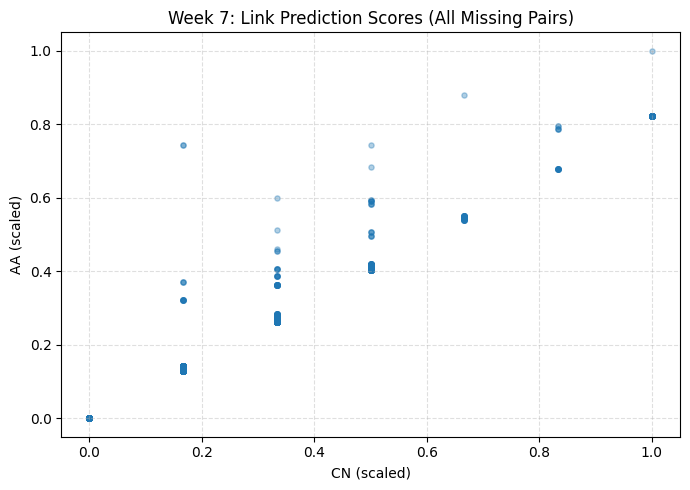

In [19]:

def common_neighbors_score(graph, u, v):
    return len(list(nx.common_neighbors(graph, u, v)))

def minmax_normalize(series):
    s_min = series.min()
    s_max = series.max()
    if s_max == s_min:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)

def build_link_prediction_dataframe(graph):
    missing_pairs = list(nx.non_edges(graph))
    aa_scores = {}

    for u, v, score in nx.adamic_adar_index(graph, ebunch=missing_pairs):
        aa_scores[(u, v)] = score
        aa_scores[(v, u)] = score

    rows = []
    for u, v in missing_pairs:
        rows.append((u, v, common_neighbors_score(graph, u, v), aa_scores[(u, v)]))

    df = pd.DataFrame(rows, columns=['u', 'v', 'CN', 'AA'])
    df['CN_scaled'] = minmax_normalize(df['CN'])
    df['AA_scaled'] = minmax_normalize(df['AA'])
    df['combined_score'] = 0.5 * (df['CN_scaled'] + df['AA_scaled'])
    return df

lp_df = build_link_prediction_dataframe(G_lcc_unweighted)

print('Top 10 predicted links by CN')
display(lp_df.sort_values(['CN', 'AA'], ascending=False).head(10).reset_index(drop=True))

print('Top 10 predicted links by AA')
display(lp_df.sort_values(['AA', 'CN'], ascending=False).head(10).reset_index(drop=True))

print('Top 10 predicted links by combined_score')
display(lp_df.sort_values(['combined_score', 'CN', 'AA'], ascending=False).head(10).reset_index(drop=True))

plt.figure(figsize=(7, 5))
plt.scatter(lp_df['CN_scaled'], lp_df['AA_scaled'], alpha=0.35, s=14)
plt.xlabel('CN (scaled)')
plt.ylabel('AA (scaled)')
plt.title('Week 7: Link Prediction Scores (All Missing Pairs)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---

## From Structure to Models

The analyses so far have mapped the static skeleton of the Season 1 network, who connects to whom, how tightly neighbourhoods close, which characters sit at structural crossroads, how the network partitions into communities, and which missing ties the topology anticipates. Taken together, they paint a consistent picture: a small core of protagonists anchors a sparse, hub-driven social world where peripheral characters attach episodically.

The natural next question is *why* this structure arises and *what it enables*. Two model-based extensions address this:

**Week 9** asks whether the observed degree inequality and hub concentration are well-explained by a preferential-attachment process, characters who are already well-connected attract new interactions more easily.

**Week 10** asks what this topology means for dynamics, specifically how quickly and how far information (or influence) can cascade through the network depending on where it starts and how transmissible it is.

Both analyses work on the same Season 1 graph, rebuilt here from scratch to ensure clean, reproducible state for the modelling stage.

The Season 1 graph is explicitly rebuilt in the cell below using the same parsing constraint as Week 1 (stop at `#s2e1`). Weighted and unweighted versions are both derived here and reused throughout Weeks 9 and 10.

In [20]:

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

G_season1 = nx.Graph()

with open("friends_episodes.txt", "r", encoding="utf-8") as f:
    for line in f:
        marker = line.strip().lower().replace(" ", "")
        if marker.startswith("#s2e1"):
            break

        
        if "]" in line:
            line = line.split("]")[-1]

        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split()
        if len(parts) >= 2:
            u, v = parts[0], parts[1]
            if G_season1.has_edge(u, v):
                G_season1[u][v]["weight"] += 1
            else:
                G_season1.add_edge(u, v, weight=1)

print("Season 1 graph rebuilt.")
print("Nodes:", G_season1.number_of_nodes())
print("Edges:", G_season1.number_of_edges())

G_season1_u = nx.Graph()
G_season1_u.add_nodes_from(G_season1.nodes())
G_season1_u.add_edges_from(G_season1.edges())
G_season1_u.remove_edges_from(nx.selfloop_edges(G_season1_u))


lcc_nodes_real = max(nx.connected_components(G_season1_u), key=len)
G_real_lcc = G_season1_u.subgraph(lcc_nodes_real).copy()

print("Unweighted LCC nodes:", G_real_lcc.number_of_nodes())
print("Unweighted LCC edges:", G_real_lcc.number_of_edges())

Season 1 graph rebuilt.
Nodes: 126
Edges: 281
Unweighted LCC nodes: 126
Unweighted LCC edges: 281


---

## Week 9 Random Graph Model: Preferential Attachment Variant

We chose a preferential attachment model because the degree distribution in Season 1 is clearly unequal, the six main cast members accumulate most of the interactions while the majority of guest characters have only one or two connections. This is exactly the kind of inequality that preferential attachment is built to reproduce.

The model starts from a Barabási-Albert graph and adds edges with preferential probability until the exact observed edge count is matched, guaranteeing the same average degree as the real network. The comparison shows that degree inequality is reproduced well, but average clustering and transitivity come out lower in the model. This is expected: the show places characters together repeatedly in the same small settings, Monica's apartment, Central Perk, creating triangles that a purely degree-driven mechanism simply does not produce.

In [21]:

n_real = G_season1_u.number_of_nodes()
edges_real = G_season1_u.number_of_edges()
avg_deg_real = np.mean([d for _, d in G_season1_u.degree()])

def preferential_attachment_with_edge_budget(n, target_edges, seed=42):
    rng = np.random.default_rng(seed)
    m0 = max(1, target_edges // n)
    graph = nx.barabasi_albert_graph(n=n, m=m0, seed=seed)

    while graph.number_of_edges() < target_edges:
        nodes = np.array(list(graph.nodes()))
        degrees = np.array([graph.degree(node) for node in nodes], dtype=float)
        probs = degrees / degrees.sum()
        u, v = rng.choice(nodes, size=2, replace=True, p=probs)

        if u != v and not graph.has_edge(u, v):
            graph.add_edge(int(u), int(v))

    return graph

G_pa = preferential_attachment_with_edge_budget(n=n_real, target_edges=edges_real, seed=42)
avg_deg_pa = np.mean([d for _, d in G_pa.degree()])

print(f"Real graph : n={n_real}, edges={edges_real}, avg_degree={avg_deg_real:.3f}")
print(f"PA variant : n={G_pa.number_of_nodes()}, edges={G_pa.number_of_edges()}, avg_degree={avg_deg_pa:.3f}")

lcc_nodes_pa = max(nx.connected_components(G_pa), key=len)
G_pa_lcc = G_pa.subgraph(lcc_nodes_pa).copy()

def safe_diameter(G):
    if G.number_of_nodes() <= 1:
        return np.nan
    return nx.diameter(G)

metrics = {
    "Metric": [
        "Nodes",
        "Edges",
        "Average Degree",
        "Average Clustering",
        "Transitivity",
        "LCC Nodes",
        "LCC Avg Shortest Path Length",
        "LCC Diameter",
    ],
    "Real (Season 1)": [
        G_season1_u.number_of_nodes(),
        G_season1_u.number_of_edges(),
        avg_deg_real,
        nx.average_clustering(G_season1_u),
        nx.transitivity(G_season1_u),
        G_real_lcc.number_of_nodes(),
        nx.average_shortest_path_length(G_real_lcc),
        safe_diameter(G_real_lcc),
    ],
    "PA Variant": [
        G_pa.number_of_nodes(),
        G_pa.number_of_edges(),
        avg_deg_pa,
        nx.average_clustering(G_pa),
        nx.transitivity(G_pa),
        G_pa_lcc.number_of_nodes(),
        nx.average_shortest_path_length(G_pa_lcc),
        safe_diameter(G_pa_lcc),
    ],
}

week9_comparison = pd.DataFrame(metrics)
week9_comparison

Real graph : n=126, edges=281, avg_degree=4.460
PA variant : n=126, edges=281, avg_degree=4.460


,Metric,Real (Season 1),PA Variant
0,Nodes,126.000000,126.000000
1,Edges,281.000000,281.000000
2,Average Degree,4.460317,4.460317
3,Average Clustering,0.505840,0.207530
4,Transitivity,0.159340,0.073692
5,LCC Nodes,126.000000,126.000000
6,LCC Avg Shortest Path Length,2.502857,2.809397
7,LCC Diameter,5.000000,5.000000


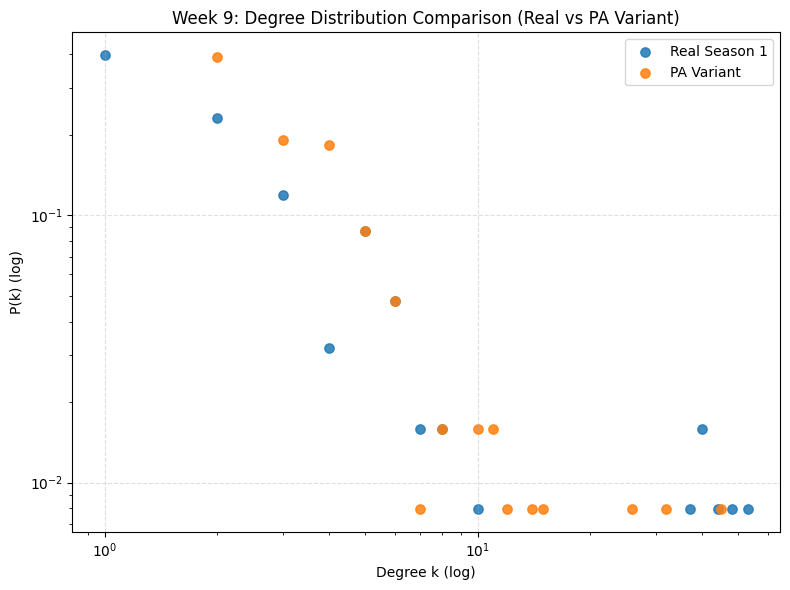

In [22]:

deg_real = np.array([d for _, d in G_season1_u.degree()])
deg_pa = np.array([d for _, d in G_pa.degree()])

def degree_pmf(degrees):
    vals, counts = np.unique(degrees, return_counts=True)
    pmf = counts / counts.sum()
    return vals, pmf

x_real, p_real = degree_pmf(deg_real)
x_pa, p_pa = degree_pmf(deg_pa)

plt.figure(figsize=(8, 6))
plt.scatter(x_real, p_real, label="Real Season 1", s=45, alpha=0.85)
plt.scatter(x_pa, p_pa, label="PA Variant", s=45, alpha=0.85)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log)")
plt.ylabel("P(k) (log)")
plt.title("Week 9: Degree Distribution Comparison (Real vs PA Variant)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

**Comment.** The preferential-attachment variant matches the real network's size and average degree by construction and reproduces the unequal degree pattern reasonably well. Its lower clustering and transitivity, however, show that popularity-driven attachment alone does not recreate the repeated triangle-rich social settings that shape the real *Friends* network.

---

## Week 10 Diffusion: Independent Cascade Model

We simulate information spread using the Independent Cascade model on the real unweighted LCC. Each newly activated node gets one attempt per neighbor per step, succeeding with probability *p*. Four scenarios are tested by varying the seed (top betweenness node, a random node, three random nodes) and the transmission probability (0.10 and 0.20), each run 250 times.

Seeding from the highest-betweenness character consistently reaches more of the network than a random start. The increase from p = 0.10 to p = 0.20 produces a disproportionately large jump in final spread, suggesting a threshold effect in this topology. Multi-seed initialization helps by reducing early die-out, instead of one cascade that might stall, you get several running in parallel across different parts of the network.

In [23]:
# WEEK 10: Independent Cascade

import random


G_diff = G_real_lcc.copy()


bet = nx.betweenness_centrality(G_diff, normalized=True)
top_seed = max(bet, key=bet.get)

def independent_cascade(graph, seeds, p=0.1, rng=None, max_steps=100):
    """
    Returns:
      activated_set: set of final activated nodes
      activated_counts: list of cumulative activated counts by step (step 0 includes initial seeds)
    """
    if rng is None:
        rng = random.Random(0)

    activated = set(seeds)
    newly_active = set(seeds)
    activated_counts = [len(activated)]

    step = 0
    while newly_active and step < max_steps:
        next_new = set()
        for u in newly_active:
            for v in graph.neighbors(u):
                if v not in activated:
                    if rng.random() < p:
                        next_new.add(v)

        next_new -= activated
        if not next_new:
            break

        activated |= next_new
        newly_active = next_new
        activated_counts.append(len(activated))
        step += 1

    return activated, activated_counts


def run_scenario(graph, seeds, p, runs=200, base_seed=123):
    final_sizes = []
    trajectories = []

    for r in range(runs):
        rng = random.Random(base_seed + r)
        activated, traj = independent_cascade(graph, seeds=seeds, p=p, rng=rng)
        final_sizes.append(len(activated))
        trajectories.append(traj)


    max_len = max(len(t) for t in trajectories)
    traj_mat = np.full((runs, max_len), np.nan)
    for i, t in enumerate(trajectories):
        traj_mat[i, :len(t)] = t
        
        if len(t) < max_len:
            traj_mat[i, len(t):] = t[-1]

    mean_traj = np.nanmean(traj_mat, axis=0)
    std_traj = np.nanstd(traj_mat, axis=0)

    return {
        "mean_final": float(np.mean(final_sizes)),
        "std_final": float(np.std(final_sizes)),
        "mean_traj": mean_traj,
        "std_traj": std_traj,
    }


nodes_list = list(G_diff.nodes())
rng_global = random.Random(2026)

random_seed_node = rng_global.choice(nodes_list)
multi_random_seeds = rng_global.sample(nodes_list, 3)

scenarios = [
    {"name": "Central seed (top betweenness), p=0.10", "seeds": [top_seed], "p": 0.10},
    {"name": "Random single seed, p=0.10", "seeds": [random_seed_node], "p": 0.10},
    {"name": "Three random seeds, p=0.10", "seeds": multi_random_seeds, "p": 0.10},
    {"name": "Central seed (top betweenness), p=0.20", "seeds": [top_seed], "p": 0.20},
]

results = {}
for sc in scenarios:
    results[sc["name"]] = run_scenario(
        graph=G_diff,
        seeds=sc["seeds"],
        p=sc["p"],
        runs=250,
        base_seed=700
    )

summary_rows = []
N = G_diff.number_of_nodes()
for sc in scenarios:
    name = sc["name"]
    summary_rows.append({
        "Scenario": name,
        "Seeds": ", ".join(sc["seeds"]),
        "p": sc["p"],
        "Mean Final Activated": results[name]["mean_final"],
        "Std Final Activated": results[name]["std_final"],
        "Mean Final Activated (%)": 100 * results[name]["mean_final"] / N
    })

week10_summary = pd.DataFrame(summary_rows).sort_values("Mean Final Activated", ascending=False)
week10_summary

,Scenario,Seeds,p,Mean Final Activated,Std Final Activated,Mean Final Activated (%)
3,"Central seed (top betweenness), p=0.20",Chandler,0.2,46.152,7.571585,36.628571
0,"Central seed (top betweenness), p=0.10",Chandler,0.1,15.300,9.778855,12.142857
2,"Three random seeds, p=0.10","MrHeckles, receptionist_1_12, Melanie",0.1,12.616,11.101556,10.012698
1,"Random single seed, p=0.10",Susan,0.1,4.920,8.024562,3.904762


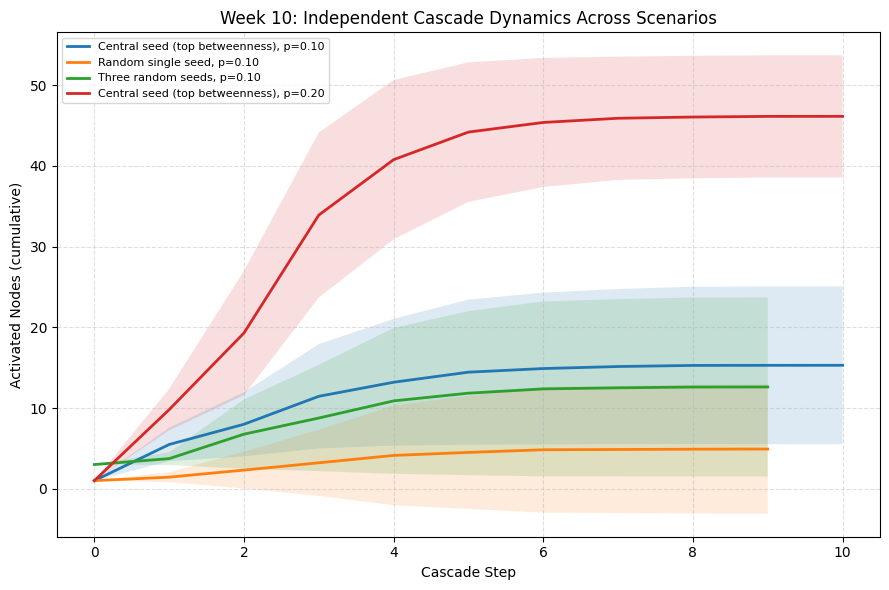

In [24]:

plt.figure(figsize=(9, 6))

for sc in scenarios:
    name = sc["name"]
    mean_traj = results[name]["mean_traj"]
    std_traj = results[name]["std_traj"]
    t = np.arange(len(mean_traj))

    plt.plot(t, mean_traj, linewidth=2, label=name)
    plt.fill_between(t, mean_traj - std_traj, mean_traj + std_traj, alpha=0.15)

plt.xlabel("Cascade Step")
plt.ylabel("Activated Nodes (cumulative)")
plt.title("Week 10: Independent Cascade Dynamics Across Scenarios")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

---

## Conclusion

The Friends Season 1 network turns out to be a clear example of a core-periphery structure, and that single observation goes a long way toward explaining almost everything we found.

The six main characters sit at the center of the network with high degree, high clustering, and strong centrality scores on both betweenness and PageRank. Around them, a layer of recurring characters, Janice, Carol, Marcel, and others, connects to the core through specific storylines. Further out, a large number of guest characters appear once or twice and drop off. The density is low overall, but that is expected: with over a hundred characters, most of whom only appear briefly, a dense network would actually be surprising.

The clustering analysis showed that the core is not only well-connected but also highly triangulated, while peripheral characters tend to connect to the center without connecting to each other. This matches what the friendship paradox would predict, and it showed up clearly in the CDF comparison in Week 3. Community detection in Week 6 picked this up too, the greedy modularity partition grouped characters by their recurring social context rather than just by degree.

The model-based weeks added some nuance. Preferential attachment can reproduce the degree inequality but not the clustering, which makes sense: the show's structure is driven by repeated scenes in shared locations, not just by popularity. And the diffusion experiments confirmed that the core does what you would expect a core to do, cascade reach is much larger and faster when the outbreak starts there.

Overall this was a useful exercise in seeing how much structure a simple interaction network can carry.